<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%204/Lagrange_Interpolation_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INTERPOLASI LAGRANGE
Data titik:
  (0, 1)
  (1, 3)
  (2, 2)
  (3, 5)
  (4, 4)

Langkah 1: Menyusun polinomial basis Lagrange L_i(x)
  L_0(x) = (x - 4)*(x - 3)*(x - 2)*(x - 1)/24
  L_1(x) = -x*(x - 4)*(x - 3)*(x - 2)/6
  L_2(x) = x*(x - 4)*(x - 3)*(x - 1)/4
  L_3(x) = -x*(x - 4)*(x - 2)*(x - 1)/6
  L_4(x) = x*(x - 3)*(x - 2)*(x - 1)/24

Langkah 2: Menjumlahkan y_i * L_i(x)
  P(x) = -5*x**4/8 + 59*x**3/12 - 95*x**2/8 + 115*x/12 + 1



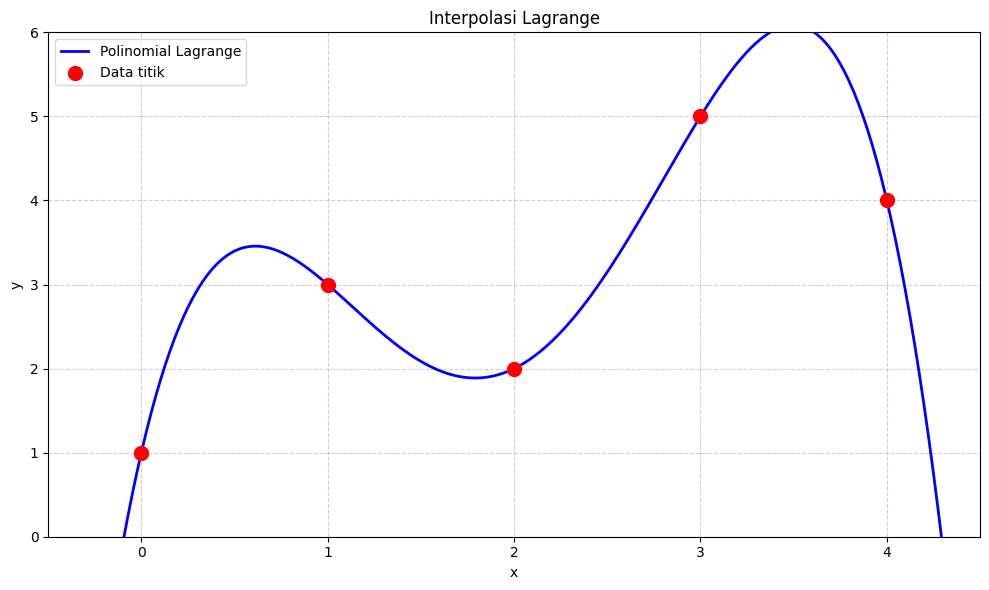

In [2]:
"""
Interpolasi Lagrange - Langkah demi langkah
Data: (0,1), (1,3), (2,2), (3,5), (4,4)
"""

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Data titik
x_points = np.array([0, 1, 2, 3, 4])
y_points = np.array([1, 3, 2, 5, 4])
n = len(x_points)

print("=" * 60)
print("INTERPOLASI LAGRANGE")
print("=" * 60)
print("Data titik:")
for i in range(n):
    print(f"  ({x_points[i]}, {y_points[i]})")
print()

# Variabel simbolik
x_sym = sp.Symbol('x')

# Konstruksi polinomial Lagrange
lagrange_poly = 0
print("Langkah 1: Menyusun polinomial basis Lagrange L_i(x)")
for i in range(n):
    # Basis L_i(x)
    basis = 1
    for j in range(n):
        if j != i:
            basis *= (x_sym - x_points[j]) / (x_points[i] - x_points[j])
    print(f"  L_{i}(x) = {sp.simplify(basis)}")
    lagrange_poly += y_points[i] * basis

# Sederhanakan
lagrange_poly = sp.expand(lagrange_poly)
print("\nLangkah 2: Menjumlahkan y_i * L_i(x)")
print(f"  P(x) = {lagrange_poly}")
print()

# Evaluasi numerik untuk plot
def lagrange_eval(x):
    result = 0
    for i in range(n):
        term = y_points[i]
        for j in range(n):
            if j != i:
                term *= (x - x_points[j]) / (x_points[i] - x_points[j])
        result += term
    return result

# Plot
x_plot = np.linspace(-0.5, 4.5, 200)
y_plot = [lagrange_eval(x) for x in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, 'b-', label='Polinomial Lagrange', linewidth=2)
plt.scatter(x_points, y_points, color='red', s=100, zorder=5, label='Data titik')
plt.title('Interpolasi Lagrange')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(-0.5, 4.5)
plt.ylim(min(y_points)-1, max(y_points)+1)
plt.tight_layout()
plt.show()